# **📄 Document type classification baseline code**
> 문서 타입 분류 대회에 오신 여러분 환영합니다! 🎉     
> 아래 baseline에서는 ResNet 모델을 로드하여, 모델을 학습 및 예측 파일 생성하는 프로세스에 대해 알아보겠습니다.

## Contents
- Prepare Environments
- Import Library & Define Functions
- Hyper-parameters
- Load Data
- Train Model
- Inference & Save File


## 1. Prepare Environments

* 데이터 로드를 위한 구글 드라이브를 마운트합니다.
* 필요한 라이브러리를 설치합니다.

In [2]:
# 구글 드라이브 마운트, Colab을 이용하지 않는다면 패스해도 됩니다.
!wget https://aistages-api-public-prod.s3.amazonaws.com/app/Competitions/000407/data/data.tar.gz ~ /data.tar.gz

--2026-01-23 07:04:30--  https://aistages-api-public-prod.s3.amazonaws.com/app/Competitions/000407/data/data.tar.gz
Resolving aistages-api-public-prod.s3.amazonaws.com (aistages-api-public-prod.s3.amazonaws.com)... 3.5.189.24, 3.5.187.98, 3.5.185.126, ...
Connecting to aistages-api-public-prod.s3.amazonaws.com (aistages-api-public-prod.s3.amazonaws.com)|3.5.189.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 392878122 (375M) [binary/octet-stream]
Saving to: ‘data.tar.gz’

data.tar.gz         100%[===================>] 374.68M  34.5MB/s    in 11s     

2026-01-23 07:04:41 (35.0 MB/s) - ‘data.tar.gz’ saved [392878122/392878122]

/data/ephemeral/home: Scheme missing.
/data.tar.gz: Scheme missing.
FINISHED --2026-01-23 07:04:41--
Total wall clock time: 11s
Downloaded: 1 files, 375M in 11s (35.0 MB/s)


In [ ]:
# 구글 드라이브에 업로드된 대회 데이터를 압축 해제하고 로컬에 저장합니다.
!tar -xvf my_fork/document-type-classification-cv-3/baseline_code/code/data.tar.gz > /dev/null

In [ ]:
# 필요한 라이브러리를 설치합니다.
!pip install timm
!pip install seaborn

## 2. Import Library & Define Functions
* 학습 및 추론에 필요한 라이브러리를 로드합니다.
* 학습 및 추론에 필요한 함수와 클래스를 정의합니다.

In [1]:
import os
import time
import random

import timm
import torch
import albumentations as A
import pandas as pd
import numpy as np
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from torch.optim import Adam
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

In [2]:
# 시드를 고정합니다.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

In [3]:
# 데이터셋 클래스를 정의합니다.
class ImageDataset(Dataset):
    def __init__(self, csv, path, transform=None):
        self.df = pd.read_csv(csv).values
        self.path = path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        name, target = self.df[idx]
        img = np.array(Image.open(os.path.join(self.path, name)))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, target

In [4]:
# one epoch 학습을 위한 함수입니다.
def train_one_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    train_loss = 0
    preds_list = []
    targets_list = []

    pbar = tqdm(loader)
    for image, targets in pbar:
        image = image.to(device)
        targets = targets.to(device)

        model.zero_grad(set_to_none=True)

        preds = model(image)
        loss = loss_fn(preds, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds_list.extend(preds.argmax(dim=1).detach().cpu().numpy())
        targets_list.extend(targets.detach().cpu().numpy())

        pbar.set_description(f"Loss: {loss.item():.4f}")

    train_loss /= len(loader)
    train_acc = accuracy_score(targets_list, preds_list)
    train_f1 = f1_score(targets_list, preds_list, average='macro')

    ret = {
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
    }

    return ret

## 3. Hyper-parameters
* 학습 및 추론에 필요한 하이퍼파라미터들을 정의합니다.

In [5]:
# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# data config
data_path = 'datasets_fin/'

# model config
model_name = 'resnet34' # 'resnet50' 'efficientnet-b0', ...

# training config
img_size = 512
# LR = 2.5e-3
# LR = 0.0003125
# LR = 7.8125e-5
LR = 1e-3
EPOCHS = 10
BATCH_SIZE = 32
# BATCH_SIZE = 4
# BATCH_SIZE = 1
num_workers = 0

## 4. Load Data
* 학습, 테스트 데이터셋과 로더를 정의합니다.

In [6]:
# augmentation을 위한 transform 코드
trn_transform = A.Compose([
    # 이미지 크기 조정
    A.Resize(height=img_size, width=img_size),
    # images normalization
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # numpy 이미지나 PIL 이미지를 PyTorch 텐서로 변환
    ToTensorV2(),
])

# test image 변환을 위한 transform 코드
tst_transform = A.Compose([
    A.Resize(height=img_size, width=img_size),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

In [7]:
# Dataset 정의
trn_dataset = ImageDataset(
    "/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data/train.csv",
    "/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data/train",
    transform=trn_transform
)
tst_dataset = ImageDataset(
    "/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data/sample_submission.csv",
    "/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data/test",
    transform=tst_transform
)
print(len(trn_dataset), len(tst_dataset))

1570 3140


In [8]:
# DataLoader 정의
trn_loader = DataLoader(
    trn_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=False
)
tst_loader = DataLoader(
    tst_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

## 5. Train Model
* 모델을 로드하고, 학습을 진행합니다.

In [9]:
# load model
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=17
).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

In [10]:
for epoch in range(EPOCHS):
    ret = train_one_epoch(trn_loader, model, optimizer, loss_fn, device=device)
    ret['epoch'] = epoch

    log = ""
    for k, v in ret.items():
      log += f"{k}: {v:.4f}\n"
    print(log)

Loss: 1.4537: 100%|██████████| 50/50 [00:19<00:00,  2.52it/s]


train_loss: 1.6220
train_acc: 0.5930
train_f1: 0.5493
epoch: 0.0000



Loss: 1.1696: 100%|██████████| 50/50 [00:18<00:00,  2.75it/s]


train_loss: 0.4223
train_acc: 0.8701
train_f1: 0.8381
epoch: 1.0000



Loss: 1.0764: 100%|██████████| 50/50 [00:18<00:00,  2.73it/s]


...

train_loss: 0.0831
train_acc: 0.9847
train_f1: 0.9844
epoch: 7.0000



Loss: 1.7117: 100%|██████████| 50/50 [00:18<00:00,  2.76it/s]


train_loss: 0.0837
train_acc: 0.9860
train_f1: 0.9844
epoch: 8.0000



Loss: 1.0191: 100%|██████████| 50/50 [00:18<00:00,  2.75it/s]

train_loss: 0.0583
train_acc: 0.9911
train_f1: 0.9895
epoch: 9.0000



100%|██████████| 50/50 [00:12<00:00,  4.10it/s]


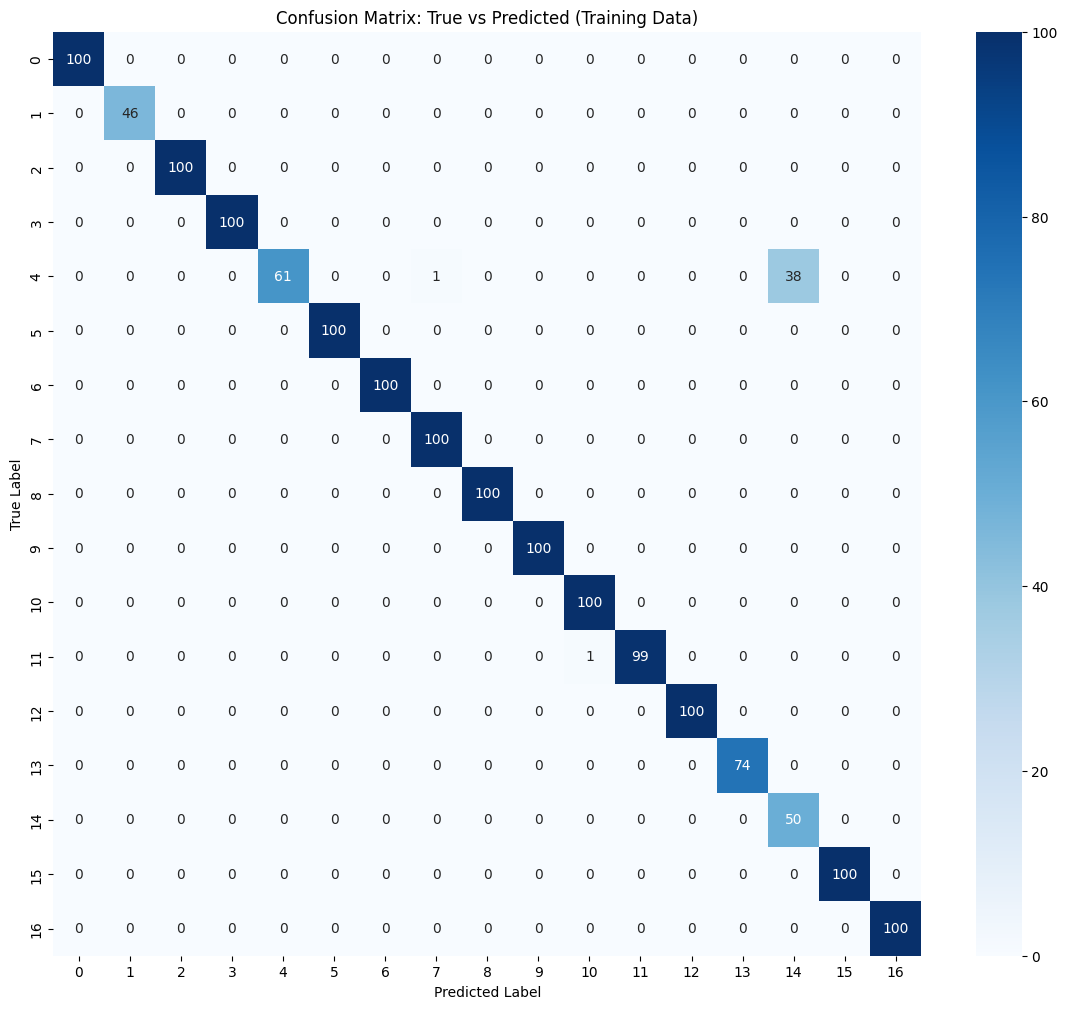

In [11]:
# Make predictions on the training data to create a confusion matrix
preds_list_train = []
true_labels_train = []

model.eval() # Set the model to evaluation mode
for image, targets in tqdm(trn_loader):
    image = image.to(device)
    true_labels_train.extend(targets.detach().cpu().numpy())

    with torch.no_grad():
        preds = model(image)
    preds_list_train.extend(preds.argmax(dim=1).detach().cpu().numpy())

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for training data
cm_train = confusion_matrix(true_labels_train, preds_list_train)

# Get the number of unique classes from the training data
# Since num_classes is 17 for this problem, we can use that directly or infer from true_labels_train
num_classes_train = len(np.unique(true_labels_train))
class_labels_train = [str(i) for i in range(num_classes_train)]

# Plotting the confusion matrix for training data
plt.figure(figsize=(14, 12))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_train, yticklabels=class_labels_train)
plt.title('Confusion Matrix: True vs Predicted (Training Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Inference & Save File
* 테스트 이미지에 대한 추론을 진행하고, 결과 파일을 저장합니다.

In [12]:
preds_list = []

model.eval()
for image, _ in tqdm(tst_loader):
    image = image.to(device)

    with torch.no_grad():
        preds = model(image)
    preds_list.extend(preds.argmax(dim=1).detach().cpu().numpy())

100%|██████████| 99/99 [00:23<00:00,  4.24it/s]


In [13]:
pred_df = pd.DataFrame(tst_dataset.df, columns=['ID', 'target'])
pred_df['target'] = preds_list

In [14]:
sample_submission_df = pd.read_csv("/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data/sample_submission.csv")
assert (sample_submission_df['ID'] == pred_df['ID']).all()

In [15]:
pred_df.to_csv("pred.csv", index=False)

In [16]:
pred_df.head()

,ID,target
0,0008fdb22ddce0ce.jpg,2
1,00091bffdffd83de.jpg,0
2,00396fbc1f6cc21d.jpg,9
3,00471f8038d9c4b6.jpg,0
4,00901f504008d884.jpg,2


# EDA


/tmp/ipykernel_237070/3455556810.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_class_counts.index, y=train_class_counts.values, palette='viridis')


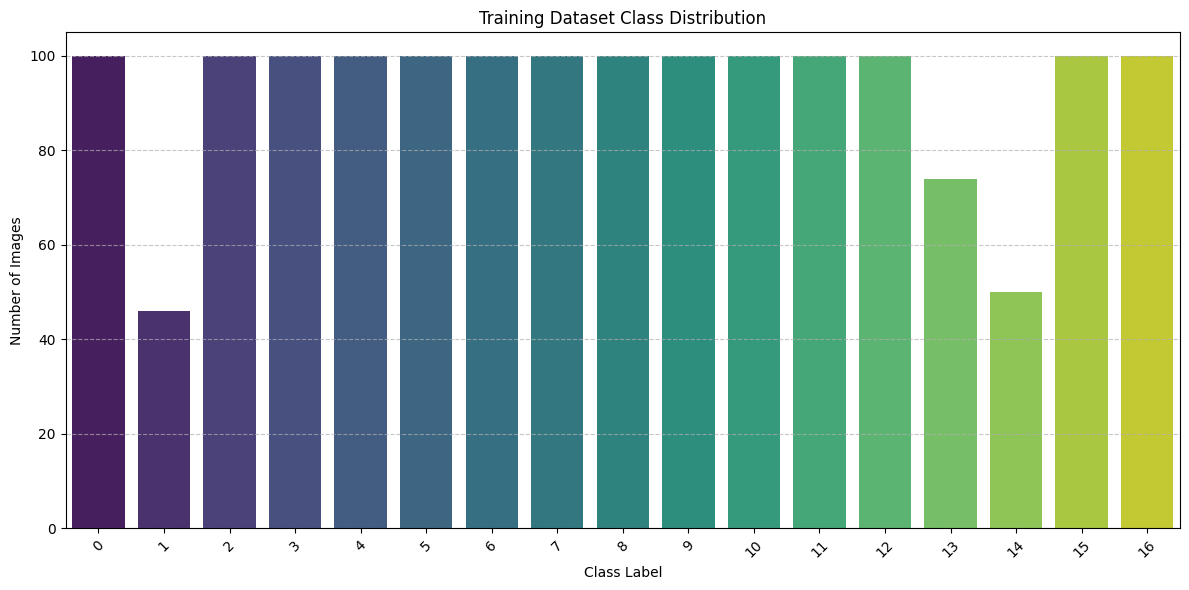

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class distribution for training dataset
train_class_counts = pd.Series(trn_dataset.df[:, 1]).value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=train_class_counts.index, y=train_class_counts.values, palette='viridis')
plt.title('Training Dataset Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import os
from PIL import Image
from tqdm import tqdm

def extract_image_properties(dataset):
    dimensions = []
    brightness_vals = []
    r_vals = []
    g_vals = []
    b_vals = []

    print(f"Processing {len(dataset)} images...")

    # 데이터셋 순회
    for i in tqdm(range(len(dataset))):
        # ImageDataset 클래스의 구조에 맞게 파일 경로 생성
        # dataset.df는 [파일명, 라벨] 형태의 numpy array입니다.
        file_name = dataset.df[i][0]
        img_path = os.path.join(dataset.path, file_name)

        try:
            with Image.open(img_path) as img:
                img = img.convert('RGB') # RGB로 변환

                # 1. 이미지 크기 (Width, Height) 저장 -> train_dimensions가 됩니다
                dimensions.append(img.size)

                # 계산을 위해 numpy array로 변환
                img_array = np.array(img)

                # 2. 밝기 계산 (Grayscale 변환 공식: 0.299R + 0.587G + 0.114B)
                brightness = np.mean(0.299 * img_array[:,:,0] + 0.587 * img_array[:,:,1] + 0.114 * img_array[:,:,2])
                brightness_vals.append(brightness)

                # 3. RGB 채널별 평균값 저장
                r_vals.append(np.mean(img_array[:,:,0]))
                g_vals.append(np.mean(img_array[:,:,1]))
                b_vals.append(np.mean(img_array[:,:,2]))

        except Exception as e:
            print(f"Error processing {file_name}: {e}")

    return dimensions, brightness_vals, r_vals, g_vals, b_vals

# --- 실행 부분 ---
print("학습 데이터 분석 중...")
train_dimensions, train_brightness, train_r_pixels, train_g_pixels, train_b_pixels = extract_image_properties(trn_dataset)

print("테스트 데이터 분석 중...")
test_dimensions, test_brightness, test_r_pixels, test_g_pixels, test_b_pixels = extract_image_properties(tst_dataset)

print("완료! 이제 시각화 코드를 실행할 수 있습니다.")

학습 데이터 분석 중...
Processing 1570 images...


100%|██████████| 1570/1570 [00:06<00:00, 226.09it/s]


테스트 데이터 분석 중...
Processing 3140 images...


100%|██████████| 3140/3140 [00:13<00:00, 226.97it/s]

완료! 이제 시각화 코드를 실행할 수 있습니다.


/tmp/ipykernel_237070/1327260708.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(train_stats['min_width'], train_stats['min_height'], color='green', marker='x', s=200, label=f"Train Min ({train_stats['min_width']:.0f}, {train_stats['min_height']:.0f})", edgecolor='black', zorder=5)


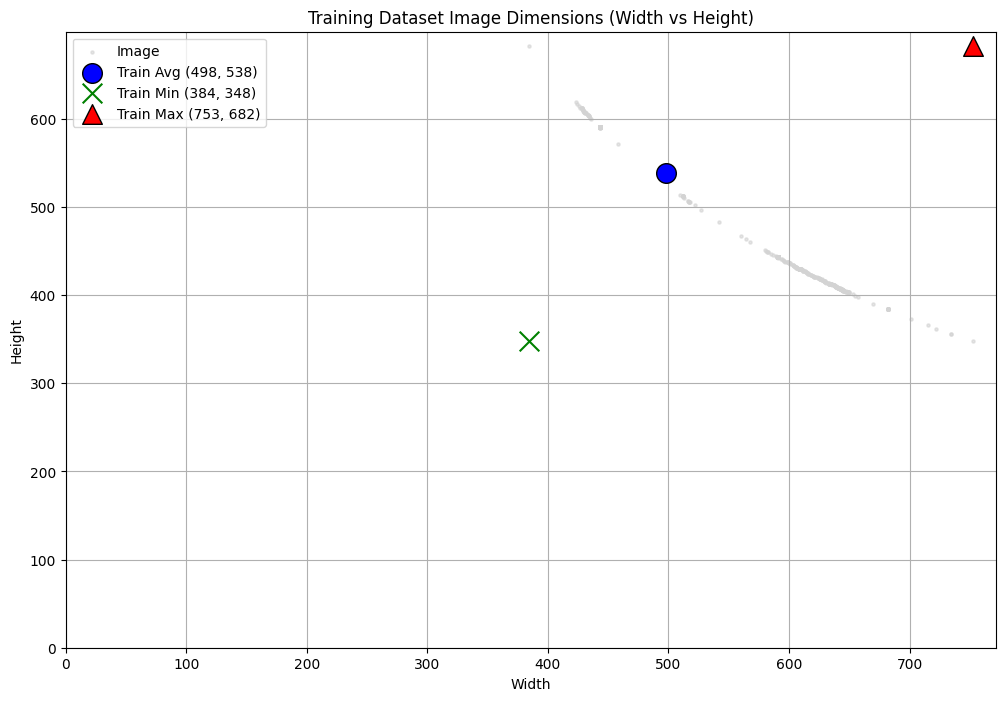

In [19]:
import matplotlib.pyplot as plt

# Calculate statistics for training dimensions (if not already calculated)
train_widths = [d[0] for d in train_dimensions]
train_heights = [d[1] for d in train_dimensions]

train_stats = {
    'avg_width': np.mean(train_widths),
    'avg_height': np.mean(train_heights),
    'min_width': np.min(train_widths),
    'min_height': np.min(train_heights),
    'max_width': np.max(train_widths),
    'max_height': np.max(train_heights)
}

plt.figure(figsize=(12, 8))

# Plot all individual training image dimensions
plt.scatter(train_widths, train_heights, color='lightgray', s=5, alpha=0.6, label='Image')

# Plot Training Data Statistics
plt.scatter(train_stats['avg_width'], train_stats['avg_height'], color='blue', marker='o', s=200, label=f"Train Avg ({train_stats['avg_width']:.0f}, {train_stats['avg_height']:.0f})", edgecolor='black', zorder=5)
plt.scatter(train_stats['min_width'], train_stats['min_height'], color='green', marker='x', s=200, label=f"Train Min ({train_stats['min_width']:.0f}, {train_stats['min_height']:.0f})", edgecolor='black', zorder=5)
plt.scatter(train_stats['max_width'], train_stats['max_height'], color='red', marker='^', s=200, label=f"Train Max ({train_stats['max_width']:.0f}, {train_stats['max_height']:.0f})", edgecolor='black', zorder=5)

plt.title('Training Dataset Image Dimensions (Width vs Height)')
plt.xlabel('Width')
plt.ylabel('Height')
plt.legend()
plt.grid(True)
plt.xlim(0) # Set x-axis limit to start from 0
plt.ylim(0) # Set y-axis limit to start from 0
plt.show()

/tmp/ipykernel_237070/604303579.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(test_stats['min_width'], test_stats['min_height'], color='green', marker='x', s=200, label=f"Test Min ({test_stats['min_width']:.0f}, {test_stats['min_height']:.0f})", edgecolor='black', zorder=5)


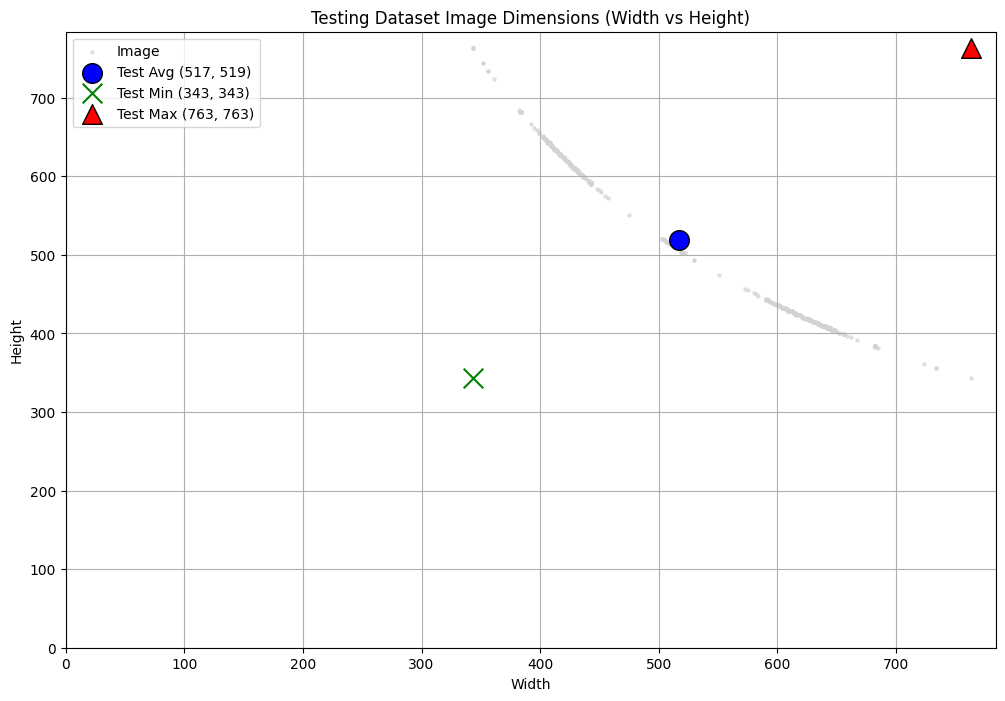

In [20]:
import matplotlib.pyplot as plt

# Calculate statistics for testing dimensions (if not already calculated)
test_widths = [d[0] for d in test_dimensions]
test_heights = [d[1] for d in test_dimensions]

test_stats = {
    'avg_width': np.mean(test_widths),
    'avg_height': np.mean(test_heights),
    'min_width': np.min(test_widths),
    'min_height': np.min(test_heights),
    'max_width': np.max(test_widths),
    'max_height': np.max(test_heights)
}

plt.figure(figsize=(12, 8))

# Plot all individual testing image dimensions
plt.scatter(test_widths, test_heights, color='lightgray', s=5, alpha=0.6, label='Image')

# Plot Testing Data Statistics
plt.scatter(test_stats['avg_width'], test_stats['avg_height'], color='blue', marker='o', s=200, label=f"Test Avg ({test_stats['avg_width']:.0f}, {test_stats['avg_height']:.0f})", edgecolor='black', zorder=5)
plt.scatter(test_stats['min_width'], test_stats['min_height'], color='green', marker='x', s=200, label=f"Test Min ({test_stats['min_width']:.0f}, {test_stats['min_height']:.0f})", edgecolor='black', zorder=5)
plt.scatter(test_stats['max_width'], test_stats['max_height'], color='red', marker='^', s=200, label=f"Test Max ({test_stats['max_width']:.0f}, {test_stats['max_height']:.0f})", edgecolor='black', zorder=5)

plt.title('Testing Dataset Image Dimensions (Width vs Height)')
plt.xlabel('Width')
plt.ylabel('Height')
plt.legend()
plt.grid(True)
plt.xlim(0) # Set x-axis limit to start from 0
plt.ylim(0) # Set y-axis limit to start from 0
plt.show()

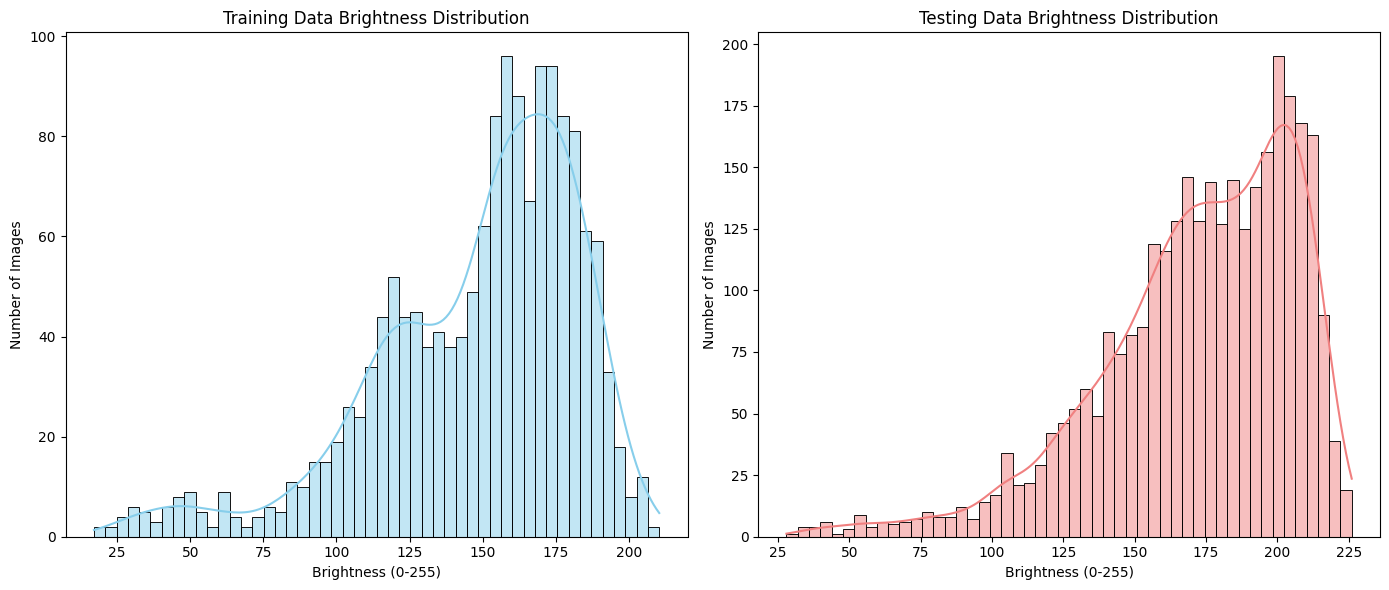


--- Brightness Statistics ---
Training Brightness: Mean=148.20, Std=35.40, Min=17.04, Max=210.40
Testing Brightness: Mean=172.20, Std=34.60, Min=27.92, Max=226.09


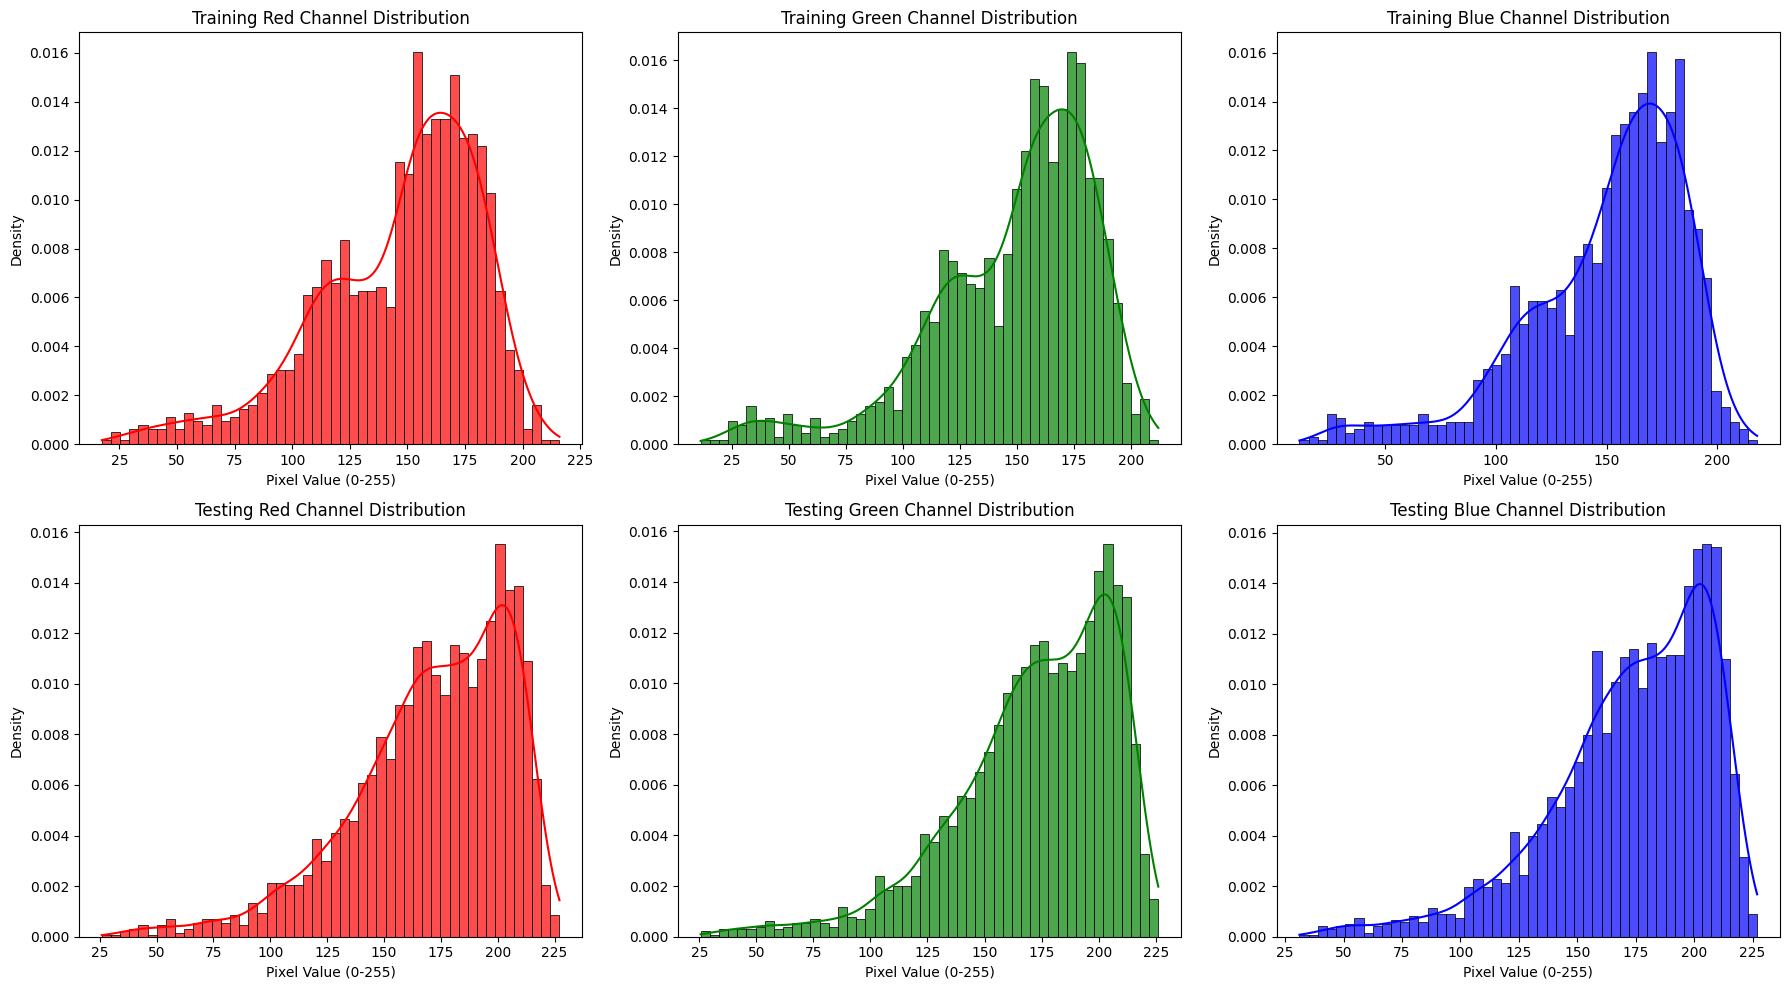


--- RGB Channel Statistics ---
Training R: Mean=146.46, Std=35.08, Min=17.41, Max=215.95
Training G: Mean=148.74, Std=35.81, Min=11.22, Max=211.96
Training B: Mean=149.99, Std=35.98, Min=11.22, Max=217.89
Testing R: Mean=171.13, Std=34.73, Min=25.91, Max=227.14
Testing G: Mean=172.54, Std=34.73, Min=25.59, Max=226.14
Testing B: Mean=173.21, Std=34.33, Min=31.08, Max=226.94


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Brightness Distribution ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(train_brightness, bins=50, color='skyblue', kde=True)
plt.title('Training Data Brightness Distribution')
plt.xlabel('Brightness (0-255)')
plt.ylabel('Number of Images')

plt.subplot(1, 2, 2)
sns.histplot(test_brightness, bins=50, color='lightcoral', kde=True)
plt.title('Testing Data Brightness Distribution')
plt.xlabel('Brightness (0-255)')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()

print("\n--- Brightness Statistics ---")
print("Training Brightness: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(train_brightness), np.std(train_brightness), np.min(train_brightness), np.max(train_brightness)))
print("Testing Brightness: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(test_brightness), np.std(test_brightness), np.min(test_brightness), np.max(test_brightness)))

# --- RGB Channel Distribution ---
plt.figure(figsize=(18, 10))

# Training RGB
plt.subplot(2, 3, 1)
sns.histplot(train_r_pixels, bins=50, color='red', kde=True, stat='density', alpha=0.7)
plt.title('Training Red Channel Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')

plt.subplot(2, 3, 2)
sns.histplot(train_g_pixels, bins=50, color='green', kde=True, stat='density', alpha=0.7)
plt.title('Training Green Channel Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')

plt.subplot(2, 3, 3)
sns.histplot(train_b_pixels, bins=50, color='blue', kde=True, stat='density', alpha=0.7)
plt.title('Training Blue Channel Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')

# Testing RGB
plt.subplot(2, 3, 4)
sns.histplot(test_r_pixels, bins=50, color='red', kde=True, stat='density', alpha=0.7)
plt.title('Testing Red Channel Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')

plt.subplot(2, 3, 5)
sns.histplot(test_g_pixels, bins=50, color='green', kde=True, stat='density', alpha=0.7)
plt.title('Testing Green Channel Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')

plt.subplot(2, 3, 6)
sns.histplot(test_b_pixels, bins=50, color='blue', kde=True, stat='density', alpha=0.7)
plt.title('Testing Blue Channel Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

print("\n--- RGB Channel Statistics ---")
print("Training R: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(train_r_pixels), np.std(train_r_pixels), np.min(train_r_pixels), np.max(train_r_pixels)))
print("Training G: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(train_g_pixels), np.std(train_g_pixels), np.min(train_g_pixels), np.max(train_g_pixels)))
print("Training B: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(train_b_pixels), np.std(train_b_pixels), np.min(train_b_pixels), np.max(train_b_pixels)))
print("Testing R: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(test_r_pixels), np.std(test_r_pixels), np.min(test_r_pixels), np.max(test_r_pixels)))
print("Testing G: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(test_g_pixels), np.std(test_g_pixels), np.min(test_g_pixels), np.max(test_g_pixels)))
print("Testing B: Mean={:.2f}, Std={:.2f}, Min={:.2f}, Max={:.2f}".format(
    np.mean(test_b_pixels), np.std(test_b_pixels), np.min(test_b_pixels), np.max(test_b_pixels)))

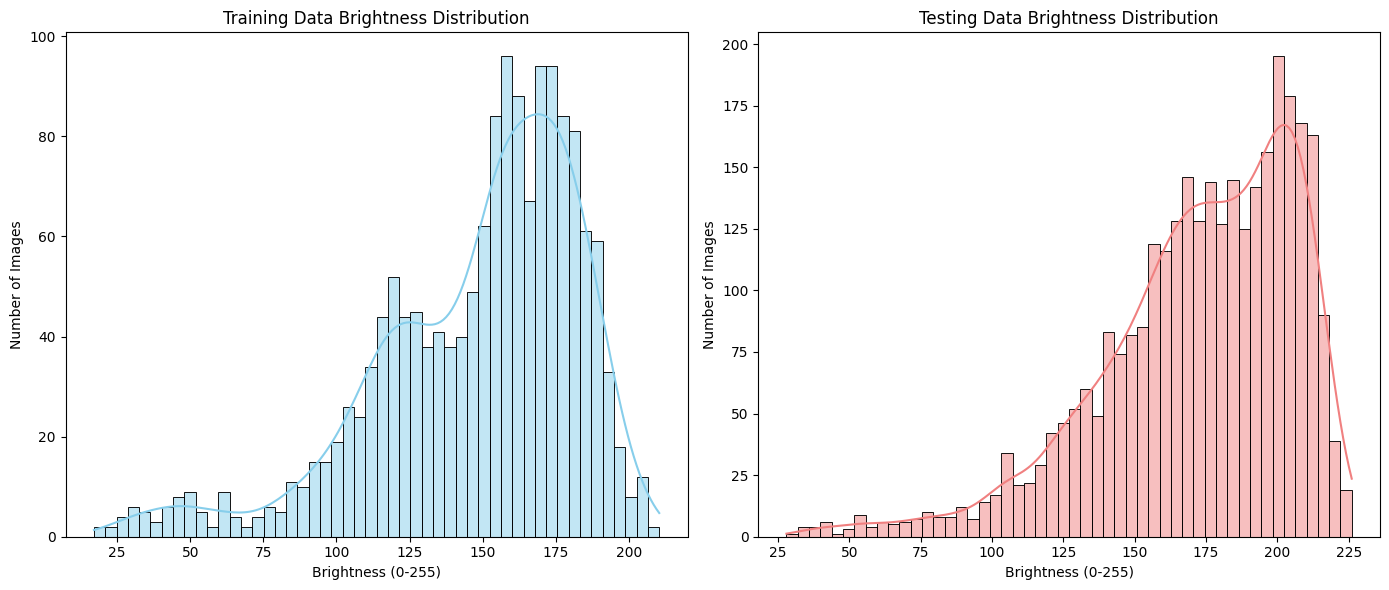

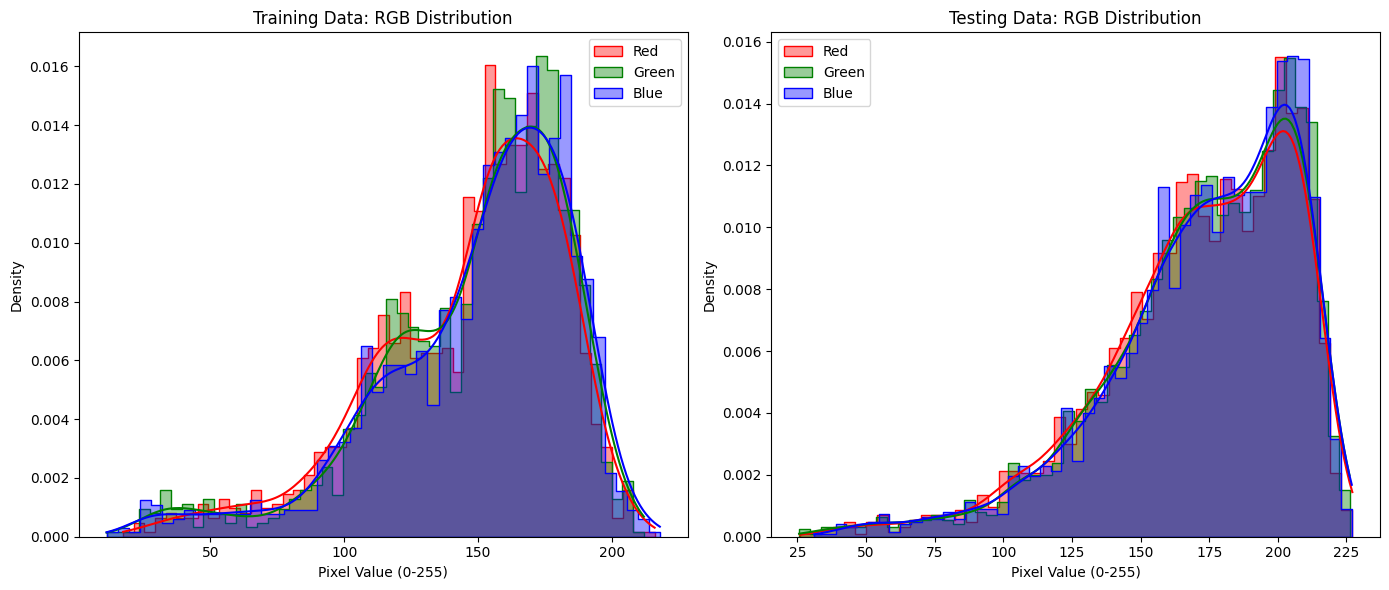


--- Brightness Statistics ---
Training Brightness: Mean=148.20
Testing Brightness:  Mean=172.20

--- RGB Channel Statistics (Mean) ---
Train - R: 146.46, G: 148.74, B: 149.99
Test  - R: 171.13, G: 172.54, B: 173.21


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Brightness Distribution (기존 코드 유지) ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(train_brightness, bins=50, color='skyblue', kde=True)
plt.title('Training Data Brightness Distribution')
plt.xlabel('Brightness (0-255)')
plt.ylabel('Number of Images')

plt.subplot(1, 2, 2)
sns.histplot(test_brightness, bins=50, color='lightcoral', kde=True)
plt.title('Testing Data Brightness Distribution')
plt.xlabel('Brightness (0-255)')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()

# --- RGB Channel Distribution (수정됨: 채널 통합) ---
plt.figure(figsize=(14, 6))

# 1. Training Data: R, G, B를 한 그래프에 겹쳐서 표시
plt.subplot(1, 2, 1)
sns.histplot(train_r_pixels, bins=50, color='red', label='Red', kde=True, stat='density', alpha=0.4, element="step")
sns.histplot(train_g_pixels, bins=50, color='green', label='Green', kde=True, stat='density', alpha=0.4, element="step")
sns.histplot(train_b_pixels, bins=50, color='blue', label='Blue', kde=True, stat='density', alpha=0.4, element="step")
plt.title('Training Data: RGB Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')
plt.legend() # 범례 추가

# 2. Testing Data: R, G, B를 한 그래프에 겹쳐서 표시
plt.subplot(1, 2, 2)
sns.histplot(test_r_pixels, bins=50, color='red', label='Red', kde=True, stat='density', alpha=0.4, element="step")
sns.histplot(test_g_pixels, bins=50, color='green', label='Green', kde=True, stat='density', alpha=0.4, element="step")
sns.histplot(test_b_pixels, bins=50, color='blue', label='Blue', kde=True, stat='density', alpha=0.4, element="step")
plt.title('Testing Data: RGB Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Density')
plt.legend() # 범례 추가

plt.tight_layout()
plt.show()

# --- Statistics Output (기존 유지) ---
print("\n--- Brightness Statistics ---")
print(f"Training Brightness: Mean={np.mean(train_brightness):.2f}")
print(f"Testing Brightness:  Mean={np.mean(test_brightness):.2f}")

print("\n--- RGB Channel Statistics (Mean) ---")
print(f"Train - R: {np.mean(train_r_pixels):.2f}, G: {np.mean(train_g_pixels):.2f}, B: {np.mean(train_b_pixels):.2f}")
print(f"Test  - R: {np.mean(test_r_pixels):.2f}, G: {np.mean(test_g_pixels):.2f}, B: {np.mean(test_b_pixels):.2f}")

In [23]:
import numpy as np

# Assuming cm_train is already defined and available from previous execution
# cm_train = np.array(...)

misclassification_rates = []
num_classes = cm_train.shape[0]

for i in range(num_classes):
    true_positive = cm_train[i, i] # Correctly classified instances of class i
    total_true_instances = np.sum(cm_train[i, :]) # Total instances of true class i

    if total_true_instances == 0:
        misclassification_rates.append((i, 0.0, None)) # No instances of this class
        continue

    # Sum of off-diagonal elements for row i (misclassified instances of class i)
    misclassified_instances = total_true_instances - true_positive
    misclassification_rate = (misclassified_instances / total_true_instances) * 100

    # Find the class it was most often confused with
    # Exclude the true positive entry itself when looking for max confusion
    row_without_diagonal = np.delete(cm_train[i, :], i)
    other_classes = np.delete(np.arange(num_classes), i)

    if len(row_without_diagonal) > 0 and np.max(row_without_diagonal) > 0:
        most_confused_with_idx = other_classes[np.argmax(row_without_diagonal)]
        most_confused_with_count = np.max(row_without_diagonal)
        misclassification_rates.append((i, misclassification_rate, most_confused_with_idx, most_confused_with_count))
    else:
        misclassification_rates.append((i, misclassification_rate, None, 0))

# Sort by misclassification rate in descending order
misclassification_rates.sort(key=lambda x: x[1], reverse=True)

print("\n--- Classes with Highest Misclassification Rates (Training Data) ---")
for class_label, rate, confused_with, count in misclassification_rates:
    if rate > 0:
        if confused_with is not None:
            print(f"Class {class_label}: {rate:.2f}% misclassified (most confused with class {confused_with} - {count} times)")
        else:
            print(f"Class {class_label}: {rate:.2f}% misclassified")
    elif rate == 0 and total_true_instances > 0:
        print(f"Class {class_label}: 0.00% misclassified (perfectly classified)")
    elif total_true_instances == 0:
        print(f"Class {class_label}: No instances in training data (cannot calculate rate)")

if misclassification_rates:
    most_confused_class_info = misclassification_rates[0]
    class_label, rate, confused_with, count = most_confused_class_info
    print(f"\nBased on the analysis, Class {class_label} appears to be the most confused, with a misclassification rate of {rate:.2f}%.")
    if confused_with is not None:
        print(f"It was most frequently misclassified as Class {confused_with}, {count} times.")


--- Classes with Highest Misclassification Rates (Training Data) ---
Class 4: 39.00% misclassified (most confused with class 14 - 38 times)
Class 11: 1.00% misclassified (most confused with class 10 - 1 times)
Class 0: 0.00% misclassified (perfectly classified)
Class 1: 0.00% misclassified (perfectly classified)
Class 2: 0.00% misclassified (perfectly classified)
Class 3: 0.00% misclassified (perfectly classified)
Class 5: 0.00% misclassified (perfectly classified)
Class 6: 0.00% misclassified (perfectly classified)
Class 7: 0.00% misclassified (perfectly classified)
Class 8: 0.00% misclassified (perfectly classified)
Class 9: 0.00% misclassified (perfectly classified)
Class 10: 0.00% misclassified (perfectly classified)
Class 12: 0.00% misclassified (perfectly classified)
Class 13: 0.00% misclassified (perfectly classified)
Class 14: 0.00% misclassified (perfectly classified)
Class 15: 0.00% misclassified (perfectly classified)
Class 16: 0.00% misclassified (perfectly classified)

Ba

In [24]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. 환경 설정 (경로)
BASE_DIR = "/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data"
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")

# 2. 데이터 로드
# (함수 밖에서 한 번만 로드하는 것이 효율적입니다)
global_df = pd.read_csv(TRAIN_CSV)

Plotting classes: [3, 4, 7, 14] with 3 samples each...


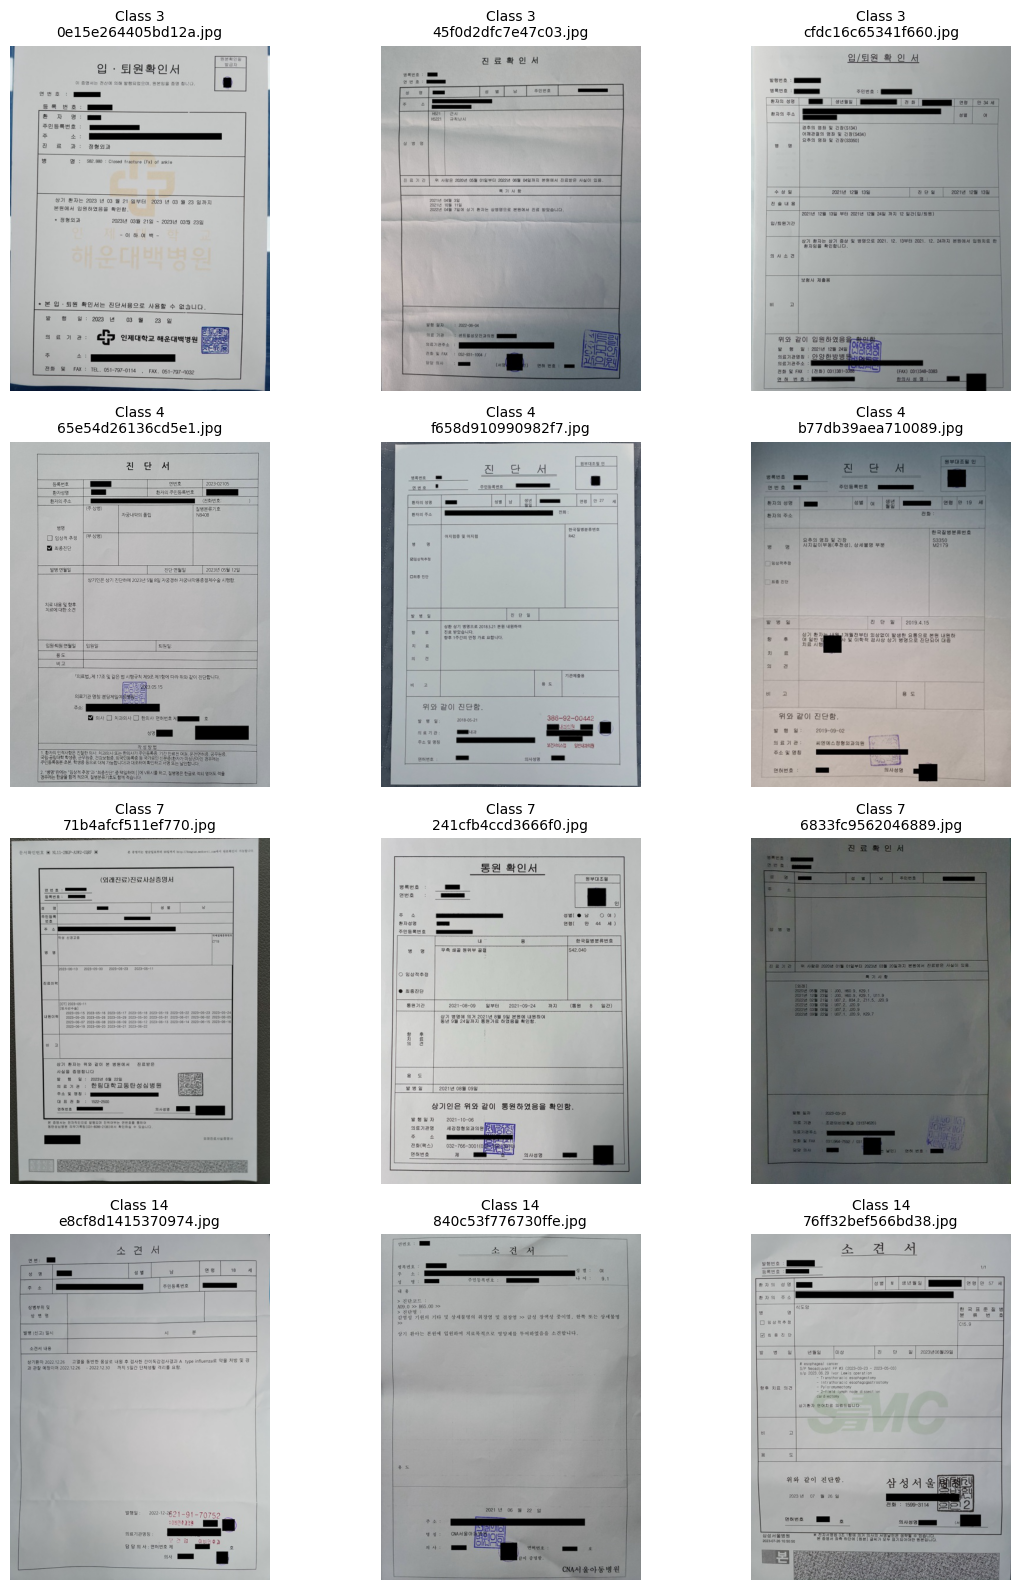

In [28]:
def plot_random_samples(class_list, n_samples, df=global_df, img_dir=TRAIN_IMG_DIR):
    """
    특정 클래스들의 이미지를 랜덤하게 샘플링하여 시각화하는 함수
    
    Args:
        class_list (list): 시각화할 클래스 번호 리스트 (예: [3, 7])
        n_samples (int): 각 클래스당 출력할 이미지 개수 (예: 3)
        df (DataFrame): 데이터프레임 (기본값: global_df)
        img_dir (str): 이미지 폴더 경로 (기본값: TRAIN_IMG_DIR)
    """
    
    n_classes = len(class_list)
    
    # 그래프 크기 및 서브플롯 생성
    # squeeze=False: 1행이나 1열일 때도 항상 2차원 배열(axes[row][col])로 접근 가능하게 함
    fig, axes = plt.subplots(n_classes, n_samples, 
                             figsize=(n_samples * 4, n_classes * 4), 
                             squeeze=False)
    
    print(f"Plotting classes: {class_list} with {n_samples} samples each...")

    for i, class_label in enumerate(class_list):
        # 해당 클래스 데이터 필터링
        class_df = df[df['target'] == class_label]
        
        # 데이터가 n_samples보다 적을 경우 처리
        current_n = min(n_samples, len(class_df))
        if current_n == 0:
            print(f"Warning: Class {class_label} has no data.")
            continue
            
        # 랜덤 샘플링
        samples = class_df.sample(n=current_n, random_state=random.randint(0, 10000))
        
        for j, (_, row) in enumerate(samples.iterrows()):
            # CSV 컬럼명 확인 (보통 'ID' 또는 'file_name')
            # 여기서는 사용자 코드에 맞춰 'ID'로 가정합니다.
            file_name = row.get('ID', row.get('file_name')) 
            img_path = os.path.join(img_dir, file_name)
            
            ax = axes[i][j]
            
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f"Class {class_label}\n{file_name}", fontsize=10)
            except Exception as e:
                ax.text(0.5, 0.5, 'Error Loading', ha='center')
                print(f"Error loading {img_path}: {e}")
            
            ax.axis('off')
            
        # 만약 샘플링한 개수가 요청 개수보다 적으면 남은 칸 끄기
        for k in range(current_n, n_samples):
             axes[i][k].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 실행 예시
# ==========================================

# 1. 3번과 7번 클래스를 각각 3개씩 보고 싶을 때
plot_random_samples([3,4, 7, 14], 3)

# 2. (응용) 1번, 3번, 7번 클래스를 각각 5개씩 보고 싶을 때
# plot_random_samples([1, 3, 7], 5)

Calculating aspect ratios for Train set...


100%|██████████| 1570/1570 [00:00<00:00, 20937.25it/s]


Calculating aspect ratios for Test set...


100%|██████████| 3140/3140 [00:00<00:00, 18104.54it/s]


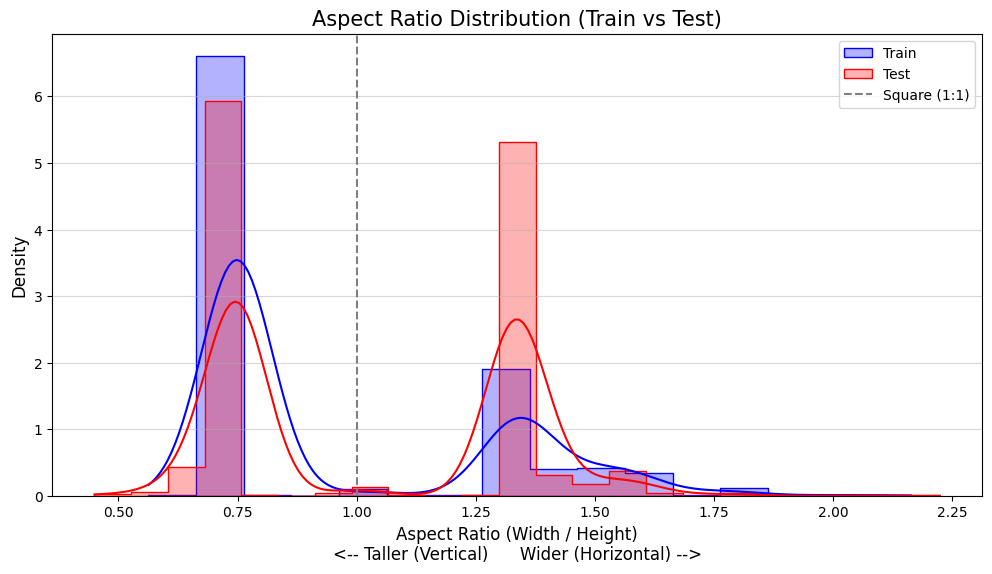


[Train] Mean AR: 0.9700, Min: 0.5630, Max: 2.1638
[Test]  Mean AR: 1.0457, Min: 0.4495, Max: 2.2245


In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# 1. 경로 설정 (사용자 환경에 맞게 수정 필요)
BASE_DIR = "/data/ephemeral/home/my_fork/document-type-classification-cv-3/baseline_code/code/data"
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")

# 테스트 데이터 경로는 sample_submission.csv를 참고하거나 test 폴더를 직접 지정
TEST_CSV = os.path.join(BASE_DIR, "sample_submission.csv")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test")

def get_aspect_ratios(img_dir, csv_path, dataset_name="Train"):
    """
    이미지 폴더와 CSV를 읽어 종횡비(Aspect Ratio) 리스트를 반환하는 함수
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"[{dataset_name}] CSV 파일을 찾을 수 없습니다: {csv_path}")
        return []

    ratios = []
    print(f"Calculating aspect ratios for {dataset_name} set...")
    
    # CSV에 있는 파일명 기준으로 순회
    # 컬럼명이 'ID'가 아닐 경우 'file_name' 등으로 자동 확인
    id_col = 'ID' if 'ID' in df.columns else df.columns[0]
    
    for file_name in tqdm(df[id_col]):
        img_path = os.path.join(img_dir, file_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                # 종횡비 계산 (Width / Height)
                ratios.append(width / height)
        except Exception as e:
            # 이미지 로드 실패 시 무시하고 진행
            pass
            
    return ratios

# 2. 데이터 수집
train_ratios = get_aspect_ratios(TRAIN_IMG_DIR, TRAIN_CSV, "Train")
test_ratios = get_aspect_ratios(TEST_IMG_DIR, TEST_CSV, "Test")

# 3. 시각화
plt.figure(figsize=(12, 6))

# 두 분포를 겹쳐서 그리기 (KDE + Histogram)
sns.histplot(train_ratios, color="blue", label="Train", kde=True, stat="density", element="step", alpha=0.3)
sns.histplot(test_ratios, color="red", label="Test", kde=True, stat="density", element="step", alpha=0.3)

# 기준선 (정사각형)
plt.axvline(x=1.0, color='gray', linestyle='--', label='Square (1:1)')

plt.title("Aspect Ratio Distribution (Train vs Test)", fontsize=15)
plt.xlabel("Aspect Ratio (Width / Height)\n<-- Taller (Vertical)      Wider (Horizontal) -->", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)

# 로그 스케일 여부 (데이터가 너무 한쪽에 쏠려있으면 주석 해제하여 사용)
# plt.xscale('log') 

plt.show()

# 4. 통계 요약 출력
print(f"\n[Train] Mean AR: {sum(train_ratios)/len(train_ratios):.4f}, Min: {min(train_ratios):.4f}, Max: {max(train_ratios):.4f}")
if test_ratios:
    print(f"[Test]  Mean AR: {sum(test_ratios)/len(test_ratios):.4f}, Min: {min(test_ratios):.4f}, Max: {max(test_ratios):.4f}")

In [27]:
save_path = 'custom_weights.pt'
torch.save(model.state_dict(), save_path)